# FemScan AI — Cervical Classifier Training

**Before you start:** Runtime > Change runtime type > **T4 GPU**

### What this notebook does
1. Clones the repo and installs dependencies
2. Mounts Google Drive (where you upload your images)
3. Copies images into the right folder structure
4. Runs `train_cervical.py` with class-weighted loss + balanced sampling
5. Saves the best checkpoint back to your Drive

### One-time Drive setup (do this before running)
Zip your `data/sipakmed/` folder locally and upload it to Google Drive:
```
# On your machine (Windows PowerShell):
cd "C:\Users\ADMIN\OneDrive\Desktop\OSBORN\HACKATHON POSTINGS\femscan-ai"
Compress-Archive -Path data\sipakmed -DestinationPath sipakmed_images.zip
```
Upload `sipakmed_images.zip` to the root of your Google Drive.

## Step 1 — GPU check

In [5]:
import torch
print('GPU available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('Device:', torch.cuda.get_device_name(0))
    print('VRAM (GB):', round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1))

GPU available: False


## Step 2 — Clone repo + install dependencies

In [6]:
import os

REPO_URL    = 'https://github.com/Donitero/CerviScan.git'
BRANCH      = 'claude/bold-heyrovsky'
REPO_DIR    = '/content/femscan-ai'

if not os.path.exists(REPO_DIR):
    !git clone --branch {BRANCH} {REPO_URL} {REPO_DIR}
else:
    !cd {REPO_DIR} && git pull

%cd {REPO_DIR}
print('Repo ready at', REPO_DIR)

Already up to date.
/content/femscan-ai
Repo ready at /content/femscan-ai


In [7]:
# Install all requirements (torch/torchvision are pre-installed on Colab,
# but we pin the rest to match requirements.txt)
!pip install -q \
    timm>=0.9.12 \
    albumentations>=1.3.1 \
    opencv-python-headless>=4.8.0 \
    scikit-learn>=1.3.0 \
    pandas>=2.1.0 \
    grad-cam>=1.5.0

print('Dependencies installed.')

Dependencies installed.


## Step 3 — Mount Drive and unzip images

In [8]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("prahladmehandiratta/cervical-cancer-largest-dataset-sipakmed")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'cervical-cancer-largest-dataset-sipakmed' dataset.
Path to dataset files: /kaggle/input/cervical-cancer-largest-dataset-sipakmed


In [9]:
import shutil
import os

# This path was provided in your output
cache_path = path
# This is where you want them to go, aligning with SRC in the next cell
target_path = '/content/femscan-ai/data/sipakmed'

# Ensure the parent directory exists for target_path
os.makedirs(target_path, exist_ok=True)

# Move them to your visible workspace
shutil.copytree(cache_path, target_path, dirs_exist_ok=True)

print(f"Files moved to {target_path}. Check the folder icon on the left!")

Files moved to /content/femscan-ai/data/sipakmed. Check the folder icon on the left!


## Step 4 — Rebuild split manifest

The manifest CSV in the repo uses Windows paths. We regenerate it here so paths point to `/content/femscan-ai/...`.

In [10]:
import csv
import shutil
from pathlib import Path
from sklearn.model_selection import train_test_split
from collections import Counter

# --- CONFIGURATION ---
PROJ      = Path('/content/femscan-ai')
SRC       = PROJ / 'data' / 'sipakmed'
OUT_CSV   = PROJ / 'data' / 'sipakmed_split.csv'
SEED      = 42

# --- STEP 1: DATA ALIGNMENT (OPTION 1) ---
# The data is expected to be moved to SRC by the previous step (uQg0p6cbY0dk)
# No need for redundant copy logic here.

# --- STEP 2: MANIFEST REBUILD ---
rows = []

# Validate SRC has content
if not any(SRC.iterdir()):
    raise FileNotFoundError(f"Source directory {SRC} is empty. Check your kagglehub download.")

# Iterate through class folders (e.g., 'Normal', 'Abnormal')
for cls_dir in sorted(SRC.iterdir()):
    if not cls_dir.is_dir() or cls_dir.name.startswith('.'):
        continue

    # SIPaKMeD often uses .bmp or .jpg; adjusted to catch all common images
    imgs = sorted([p for p in cls_dir.glob('**/*') if p.suffix.lower() in ['.png', '.jpg', '.jpeg', '.bmp']])

    n = len(imgs)
    if n == 0:
        continue

    if n < 3:
        for p in imgs:
            rows.append({'filepath': str(p.relative_to(PROJ)), 'class': cls_dir.name, 'split': 'train'})
        continue

    # Split: 70% Train, 15% Val, 15% Test
    tr, tmp = train_test_split(imgs, test_size=0.30, random_state=SEED)
    if len(tmp) >= 2:
        va, te = train_test_split(tmp, test_size=0.50, random_state=SEED)
    else:
        va, te = tmp, []

    for p in tr: rows.append({'filepath': str(p.relative_to(PROJ)), 'class': cls_dir.name, 'split': 'train'})
    for p in va: rows.append({'filepath': str(p.relative_to(PROJ)), 'class': cls_dir.name, 'split': 'val'})
    for p in te: rows.append({'filepath': str(p.relative_to(PROJ)), 'class': cls_dir.name, 'split': 'test'})

# --- STEP 3: SAVE & VERIFY ---
with open(OUT_CSV, 'w', newline='') as f:
    w = csv.DictWriter(f, fieldnames=['filepath', 'class', 'split'])
    w.writeheader()
    w.writerows(rows)

splits = Counter(r['split'] for r in rows)
print(f'--- Manifest Rebuilt ---')
print(f'Total images found: {len(rows)}')
print(f'Distribution: Train={splits["train"]}, Val={splits["val"]}, Test={splits["test"]}')
print(f'CSV saved to: {OUT_CSV}')

--- Manifest Rebuilt ---
Total images found: 5015
Distribution: Train=3508, Val=752, Test=755
CSV saved to: /content/femscan-ai/data/sipakmed_split.csv


In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Step 5 — Verify dataset loads correctly

In [12]:
import sys
sys.path.insert(0, REPO_DIR)

from scripts.train_cervical import (
    CervicalDataset, build_train_transform, build_val_transform,
    compute_class_weights, compute_sample_weights
)
from models.cervical_classifier import CLASS_NAMES
import torch

manifest = f'{REPO_DIR}/data/sipakmed_split.csv'
train_ds = CervicalDataset(manifest, 'train', build_train_transform(224))
val_ds   = CervicalDataset(manifest, 'val',   build_val_transform(224))

print(f'Train: {len(train_ds)} samples')
print(f'Val  : {len(val_ds)} samples')
print('\nClass distribution (train):')
for cls, n in sorted(train_ds.class_counts().items()):
    print(f'  {cls:<30}: {n}')

# Show class weights
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
weights = compute_class_weights(train_ds, device)
print('\nClass weights for loss:')
for cls, w in zip(CLASS_NAMES, weights.tolist()):
    bar = '#' * int(w * 5)
    print(f'  {cls:<30}: {w:.2f}  {bar}')

Train: 3508 samples
Val  : 752 samples

Class distribution (train):
  im_Dyskeratotic               : 725
  im_Koilocytotic               : 744
  im_Metaplastic                : 744
  im_Parabasal                  : 626
  im_Superficial-Intermediate   : 669

Class weights for loss:
  Negative                      : 584.67  ###################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################

/content/femscan-ai/scripts/train_cervical.py:102: UserWarning: Argument(s) 'max_holes, max_height, max_width, min_holes, fill_value' are not valid for transform CoarseDropout
  A.CoarseDropout(


In [13]:
# 1. Get unique classes from your newly created CSV
import pandas as pd
df = pd.read_csv('/content/femscan-ai/data/sipakmed_split.csv')
unique_classes = sorted(df['class'].unique())

# 2. Create the mapping dynamically (Bullet-proof method)
CLASS_NAMES = unique_classes
class_to_idx = {cls_name: i for i, cls_name in enumerate(CLASS_NAMES)}

print(f"Mapped Classes: {class_to_idx}")

# 3. Update your Dataset object (IMPORTANT)
# Assuming your dataset variable is named train_ds
train_ds.class_to_idx = class_to_idx

Mapped Classes: {'im_Dyskeratotic': 0, 'im_Koilocytotic': 1, 'im_Metaplastic': 2, 'im_Parabasal': 3, 'im_Superficial-Intermediate': 4}


✅ Image saved successfully to: /content/femscan-ai/reports/sanity_check_batch.png


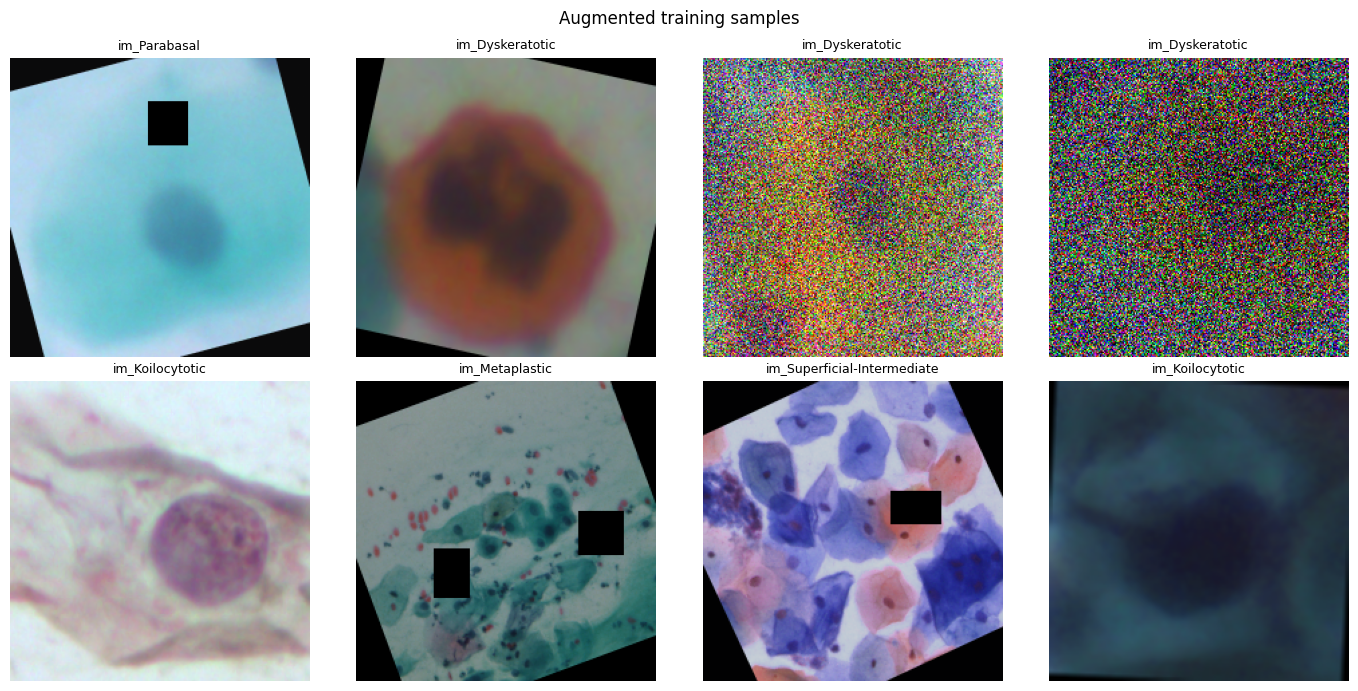

Batch shape: torch.Size([8, 3, 224, 224])


In [14]:
# Quick sanity check: load one batch and visualise
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader

loader = DataLoader(train_ds, batch_size=8, shuffle=True)
imgs, labels = next(iter(loader))

# De-normalise for display
mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
imgs_display = (imgs * std + mean).clamp(0, 1)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    ax.imshow(imgs_display[i].permute(1,2,0).numpy())
    ax.set_title(CLASS_NAMES[labels[i]], fontsize=9)
    ax.axis('off')
plt.suptitle('Augmented training samples', fontsize=12)

# --- THE SAVE STEP (MUST BE BEFORE plt.show) ---
# Create a directory if it doesn't exist
output_path = Path('/content/femscan-ai/reports/sanity_check_batch.png')
output_path.parent.mkdir(parents=True, exist_ok=True)

plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"✅ Image saved successfully to: {output_path}")

plt.tight_layout()
plt.show()
print('Batch shape:', imgs.shape)

## Step 6 — Train

Default config: **25 epochs**, freeze backbone for first 5, then fine-tune.
On a T4 GPU this takes ~8-12 minutes for 232 images.

Adjust `EPOCHS` and `BATCH_SIZE` as needed.

In [21]:
import os

content = """
from __future__ import annotations
import torch
import torch.nn as nn
import timm
from typing import Dict, Any

CLASS_META: Dict[str, Dict[str, Any]] = {
    "im_Dyskeratotic": {"category": "High-grade", "cin_grade": "HSIL / CIN2-3", "triage_color": "red", "action": "Urgent colposcopy required.", "urgency": "high", "color": "#F44336"},
    "im_Koilocytotic": {"category": "Low-grade", "cin_grade": "LSIL / CIN1", "triage_color": "amber", "action": "Repeat cytology in 6 months.", "urgency": "moderate", "color": "#FF9800"},
    "im_Metaplastic": {"category": "Normal/Reactive", "cin_grade": "No CIN", "triage_color": "green", "action": "Routine screening.", "urgency": "low", "color": "#CDDC39"},
    "im_Parabasal": {"category": "Normal/Atrophic", "cin_grade": "No CIN", "triage_color": "green", "action": "Routine screening.", "urgency": "low", "color": "#8BC34A"},
    "im_Superficial-Intermediate": {"category": "Normal", "cin_grade": "No CIN", "triage_color": "green", "action": "Routine screening.", "urgency": "low", "color": "#4CAF50"},
}

CLASS_NAMES = sorted(list(CLASS_META.keys()))
NUM_CLASSES = len(CLASS_NAMES)

class CervicalClassifier(nn.Module):
    def __init__(self, pretrained: bool = True):
        super().__init__()
        # FIX: Using 'tf_efficientnetv2_s.in1k' which is the standard pretrained identifier
        model_name = 'tf_efficientnetv2_s.in1k'
        self.backbone = timm.create_model(
            model_name,
            pretrained=pretrained,
            num_classes=NUM_CLASSES
        )

    def forward(self, x):
        return self.backbone(x)
"""

with open('/content/femscan-ai/models/cervical_classifier.py', 'w') as f:
    f.write(content.strip())

print("Model file updated with the correct timm identifier.")

Model file updated with the correct timm identifier.


In [ ]:
EPOCHS       = 25
BATCH_SIZE   = 16
FREEZE_EPOCHS = 5
LR           = 3e-4

!python {REPO_DIR}/scripts/train_cervical.py \
    --manifest  {REPO_DIR}/data/sipakmed_split.csv \
    --out-dir   {REPO_DIR}/trained_models \
    --epochs    {EPOCHS} \
    --batch-size {BATCH_SIZE} \
    --freeze-epochs {FREEZE_EPOCHS} \
    --lr        {LR}

Device: cpu
/content/femscan-ai/scripts/train_cervical.py:102: UserWarning: Argument(s) 'max_holes, max_height, max_width, min_holes, fill_value' are not valid for transform CoarseDropout
  A.CoarseDropout(

Train: 3508 samples
Val  : 752 samples

Train class distribution:
  im_Dyskeratotic               : 725
  im_Koilocytotic               : 744
  im_Metaplastic                : 744
  im_Parabasal                  : 626
  im_Superficial-Intermediate   : 669

[Strategy B] WeightedRandomSampler ON
model.safetensors: 100% 86.5M/86.5M [00:03<00:00, 22.5MB/s]

[Strategy A] Class-weighted CrossEntropyLoss:
  im_Dyskeratotic               : weight = 0.968
  im_Koilocytotic               : weight = 0.943
  im_Metaplastic                : weight = 0.943
  im_Parabasal                  : weight = 1.121
  im_Superficial-Intermediate   : weight = 1.049
/content/femscan-ai/scripts/train_cervical.py:320: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradS

## Step 7 — Save checkpoint to Google Drive

In [ ]:
import shutil, time
from pathlib import Path

src  = Path(f'{REPO_DIR}/trained_models/cervical_best.pt')
tag  = time.strftime('%Y%m%d_%H%M')
dest = Path(f'/content/drive/MyDrive/femscan_checkpoints/cervical_best_{tag}.pt')
dest.parent.mkdir(parents=True, exist_ok=True)

if src.exists():
    shutil.copy2(src, dest)
    print(f'Checkpoint saved to Drive: {dest}')
else:
    print('No checkpoint found — did training complete?')

## Step 8 — Evaluate on test set

In [ ]:
import torch
import sys
sys.path.insert(0, REPO_DIR)

from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from scripts.train_cervical import CervicalDataset, build_val_transform
from models.cervical_classifier import CervicalClassifier, CLASS_NAMES

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load best checkpoint
ckpt_path = f'{REPO_DIR}/trained_models/cervical_best.pt'
model = CervicalClassifier(pretrained=False, checkpoint_path=ckpt_path).to(device)
model.eval()
print('Loaded checkpoint from', ckpt_path)

# Test set
test_ds = CervicalDataset(
    f'{REPO_DIR}/data/sipakmed_split.csv', 'test', build_val_transform(224)
)
test_loader = DataLoader(test_ds, batch_size=16, shuffle=False)

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        preds = model(imgs).argmax(1).cpu()
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())

print('\nClassification Report:')
print(classification_report(
    all_labels, all_preds,
    target_names=CLASS_NAMES,
    zero_division=0
))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES
)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix — Test Set')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/femscan_checkpoints/confusion_matrix.png', dpi=150)
plt.show()